# Single Unit: Separators (Flash Drums)

**Prerequisites:** [00d_single_unit_cstr](./00d_single_unit_cstr.ipynb), basic thermodynamics

**Learning Objectives:**
- Understand vapor-liquid equilibrium (VLE)
- Derive and solve the Rachford-Rice equation
- Learn about K-values and their temperature/pressure dependence
- Implement a flash drum calculation

---

## What is a Flash Drum?

A **flash drum** (or flash separator) is a vessel where a liquid mixture partially vaporizes:

```
                    ┌─────────────┐
                    │   Vapor (V) │──────► Light components
                    │             │
    Feed (F) ──────►│   ~~~~~~    │
                    │   ~~~~~~    │
                    │   Liquid (L)│──────► Heavy components
                    └─────────────┘
```

**Key concept:** Components with higher vapor pressure concentrate in the vapor; components with lower vapor pressure stay in the liquid.

## Vapor-Liquid Equilibrium (VLE)

At equilibrium, the chemical potential of each component is equal in both phases. For ideal systems, this leads to **Raoult's Law**:

$$y_i P = x_i P_i^{sat}(T)$$

where:
- $y_i$ = vapor mole fraction
- $x_i$ = liquid mole fraction  
- $P$ = system pressure
- $P_i^{sat}$ = saturation (vapor) pressure of pure component $i$

### K-Values

The **K-value** (equilibrium ratio) is defined as:

$$K_i = \frac{y_i}{x_i} = \frac{P_i^{sat}(T)}{P}$$

- $K_i > 1$: Component prefers vapor phase ("light" component)
- $K_i < 1$: Component prefers liquid phase ("heavy" component)
- $K_i = 1$: No preference

In [1]:
# Setup
import os
os.environ['JAX_PLATFORM_NAME'] = 'cpu'

import jax.numpy as jnp
import jax
jax.config.update("jax_enable_x64", True)
import matplotlib.pyplot as plt
import numpy as np

from difflow import Flash, FlashParams, make_stream, get_flows, IdealThermo, SpeciesData

W0000 00:00:1765762784.716322 11155853 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1765762784.781968 11155853 service.cc:145] XLA service 0x600001510c00 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765762784.781993 11155853 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1765762784.784581 11155853 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1765762784.784597 11155853 mps_client.cc:384] XLA backend will use up to 51539132416 bytes on device 0 for SimpleAllocator.


Metal device set to: Apple M4 Pro


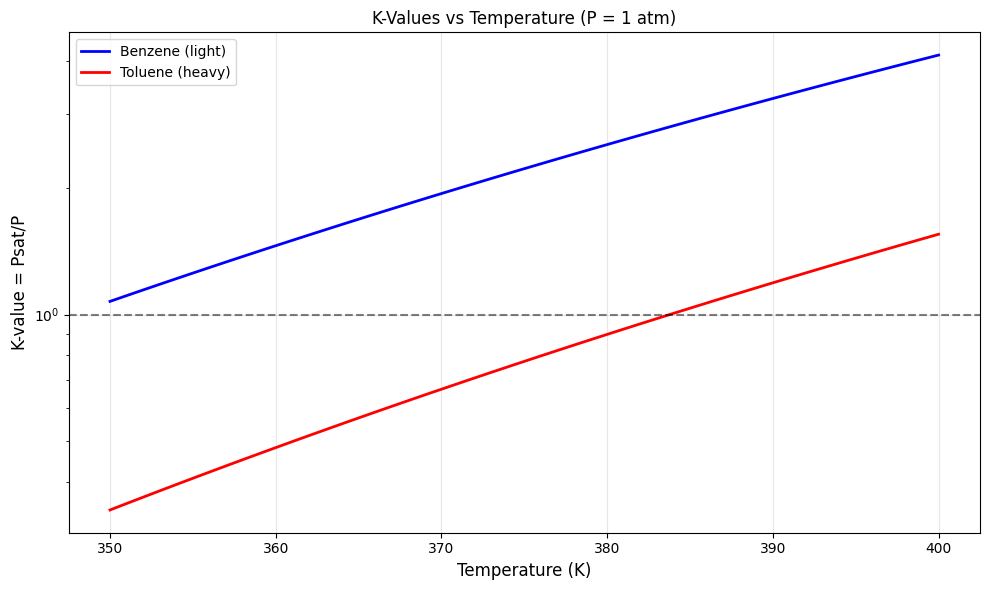

In [2]:
# Define a binary mixture: benzene (light) and toluene (heavy)

species_data = {
    'benzene': SpeciesData(
        name='benzene', MW=78.0,
        Cp_coeffs=(135.0, 0, 0, 0),
        Hvap_coeffs=(30720.0, 0.38, 562.0),
        antoine_coeffs=(9.1058, 1211.0, -52.36),  # log10(Psat/Pa)
    ),
    'toluene': SpeciesData(
        name='toluene', MW=92.0,
        Cp_coeffs=(157.0, 0, 0, 0),
        Hvap_coeffs=(33180.0, 0.38, 592.0),
        antoine_coeffs=(9.0782, 1343.9, -53.77),
    ),
}
thermo = IdealThermo(species_data)

# Calculate K-values at different temperatures
T_range = np.linspace(350, 400, 50)
P = 101325.0  # 1 atm

K_benzene = []
K_toluene = []

for T in T_range:
    K_benzene.append(float(thermo.Psat('benzene', T)) / P)
    K_toluene.append(float(thermo.Psat('toluene', T)) / P)

# Plot K-values vs temperature
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(T_range, K_benzene, 'b-', linewidth=2, label='Benzene (light)')
ax.plot(T_range, K_toluene, 'r-', linewidth=2, label='Toluene (heavy)')
ax.axhline(y=1, color='k', linestyle='--', alpha=0.5)
ax.set_xlabel('Temperature (K)', fontsize=12)
ax.set_ylabel('K-value = Psat/P', fontsize=12)
ax.set_title('K-Values vs Temperature (P = 1 atm)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')
plt.tight_layout()


## The Rachford-Rice Equation

For a flash calculation, we know:
- Feed composition $z_i$
- Temperature $T$ and pressure $P$

We want to find:
- Vapor fraction $V/F$ (what fraction vaporizes)
- Vapor composition $y_i$
- Liquid composition $x_i$

The **Rachford-Rice equation** combines material balances with VLE:

$$f(\psi) = \sum_i \frac{z_i(K_i - 1)}{1 + \psi(K_i - 1)} = 0$$

where $\psi = V/F$ is the vapor fraction.

Once we solve for $\psi$:
$$x_i = \frac{z_i}{1 + \psi(K_i - 1)}$$
$$y_i = K_i x_i$$

In [3]:
# Implement flash calculation from scratch

def rachford_rice(psi, z, K):
    """
    Rachford-Rice equation: should equal zero at solution.
    
    Args:
        psi: Vapor fraction V/F
        z: Feed mole fractions (array)
        K: K-values (array)
    """
    return jnp.sum(z * (K - 1) / (1 + psi * (K - 1)))

def solve_flash_raw(z, K, tol=1e-10):
    """
    Solve flash using Newton's method on Rachford-Rice.
    
    Returns:
        psi: Vapor fraction
        x: Liquid mole fractions
        y: Vapor mole fractions
    """
    # Initial guess
    psi = 0.5
    
    # Newton iteration
    for _ in range(50):
        f = rachford_rice(psi, z, K)
        # Derivative: df/dpsi = -sum(z*(K-1)^2 / (1+psi*(K-1))^2)
        df = -jnp.sum(z * (K - 1)**2 / (1 + psi * (K - 1))**2)
        
        delta = f / df
        psi = psi - delta
        
        # Bound psi between 0 and 1
        psi = jnp.clip(psi, 0.001, 0.999)
        
        if abs(f) < tol:
            break
    
    # Calculate compositions
    x = z / (1 + psi * (K - 1))
    y = K * x
    
    return float(psi), x, y

# Example: 50% benzene, 50% toluene at 370 K, 1 atm
z = jnp.array([0.5, 0.5])  # Equimolar feed
T = 370.0
P = 101325.0

K = jnp.array([float(thermo.Psat('benzene', T)) / P,
               float(thermo.Psat('toluene', T)) / P])

psi, x, y = solve_flash_raw(z, K)

print("Flash Calculation (From Scratch)")
print("=" * 50)
print(f"Feed: z_benzene = {z[0]:.2f}, z_toluene = {z[1]:.2f}")
print(f"T = {T} K, P = {P/1000:.1f} kPa")
print(f"K-values: K_benzene = {float(K[0]):.3f}, K_toluene = {float(K[1]):.3f}")
print(f"")
print(f"Results:")
print(f"  Vapor fraction ψ = V/F = {psi:.4f}")
print(f"  Liquid: x_benzene = {float(x[0]):.4f}, x_toluene = {float(x[1]):.4f}")
print(f"  Vapor:  y_benzene = {float(y[0]):.4f}, y_toluene = {float(y[1]):.4f}")

Flash Calculation (From Scratch)
Feed: z_benzene = 0.50, z_toluene = 0.50
T = 370.0 K, P = 101.3 kPa
K-values: K_benzene = 1.939, K_toluene = 0.665

Results:
  Vapor fraction ψ = V/F = 0.9595
  Liquid: x_benzene = 0.2630, x_toluene = 0.7370
  Vapor:  y_benzene = 0.5100, y_toluene = 0.4900


In [4]:
# Using difflow's Flash

flash_params = FlashParams(species_order=['benzene', 'toluene'])
flash = Flash(flash_params, thermo=thermo)

# Create feed stream (10 mol/s total, equimolar)
feed = make_stream({'benzene': 5.0, 'toluene': 5.0}, T=350.0, P=P)

# Flash at 370 K
liquid, vapor, info = flash(feed, T=T, P=P)

print("\nFlash Calculation (difflow)")
print("=" * 50)
liquid_flows = get_flows(liquid)
vapor_flows = get_flows(vapor)

print(f"Feed: {float(get_flows(feed)['benzene']):.2f} mol/s benzene, "
      f"{float(get_flows(feed)['toluene']):.2f} mol/s toluene")
print(f"")
print(f"Liquid:")
print(f"  Benzene: {float(liquid_flows['benzene']):.4f} mol/s")
print(f"  Toluene: {float(liquid_flows['toluene']):.4f} mol/s")
print(f"")
print(f"Vapor:")
print(f"  Benzene: {float(vapor_flows['benzene']):.4f} mol/s")
print(f"  Toluene: {float(vapor_flows['toluene']):.4f} mol/s")
print(f"")
print(f"Vapor fraction: {float(info['V_frac']):.4f}")


Flash Calculation (difflow)
Feed: 5.00 mol/s benzene, 5.00 mol/s toluene

Liquid:
  Benzene: 0.1066 mol/s
  Toluene: 0.2988 mol/s

Vapor:
  Benzene: 4.8934 mol/s
  Toluene: 4.7012 mol/s

Vapor fraction: 0.9595


## Visualizing the Flash Operation

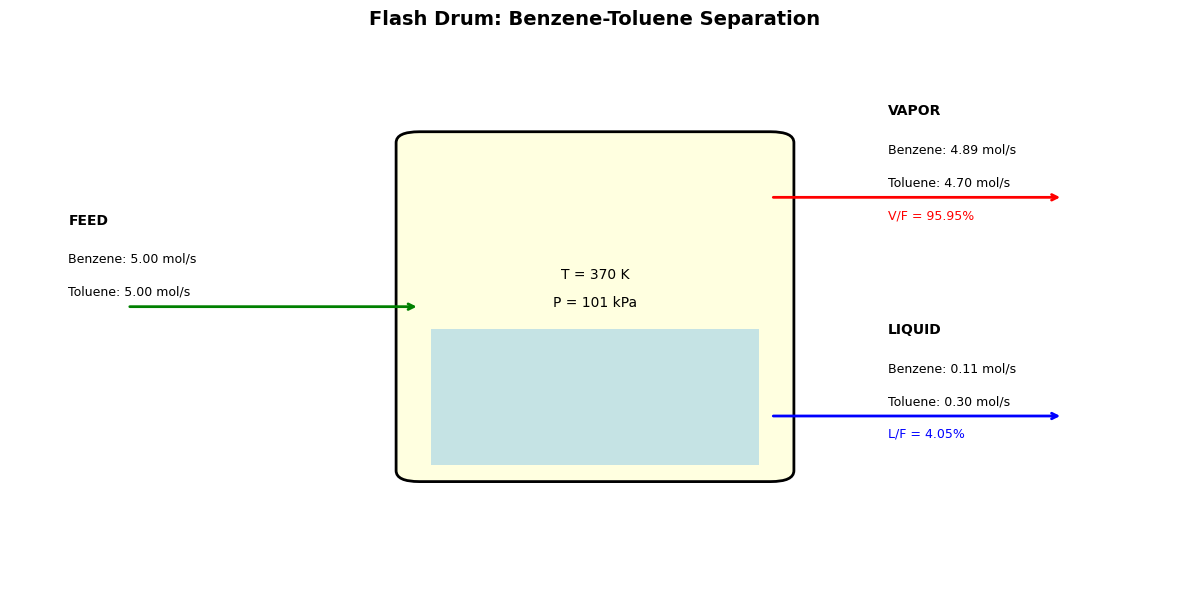

In [5]:
import matplotlib.patches as patches

def draw_flash_diagram(feed_flows, liquid_flows, vapor_flows, T, P, vapor_frac):
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Flash drum
    drum = patches.FancyBboxPatch(
        (0.35, 0.2), 0.3, 0.6,
        boxstyle="round,pad=0.02",
        facecolor='lightyellow',
        edgecolor='black',
        linewidth=2,
    )
    ax.add_patch(drum)
    
    # Liquid level
    liquid_level = patches.Rectangle(
        (0.36, 0.21), 0.28, 0.25,
        facecolor='lightblue',
        alpha=0.7,
    )
    ax.add_patch(liquid_level)
    
    ax.text(0.5, 0.55, f'T = {T:.0f} K', ha='center', fontsize=10)
    ax.text(0.5, 0.50, f'P = {P/1000:.0f} kPa', ha='center', fontsize=10)
    
    # Feed arrow
    ax.annotate('', xy=(0.35, 0.5), xytext=(0.1, 0.5),
                arrowprops=dict(arrowstyle='->', lw=2, color='green'))
    ax.text(0.05, 0.65, 'FEED', fontsize=10, fontweight='bold')
    ax.text(0.05, 0.58, f'Benzene: {feed_flows[0]:.2f} mol/s', fontsize=9)
    ax.text(0.05, 0.52, f'Toluene: {feed_flows[1]:.2f} mol/s', fontsize=9)
    
    # Vapor arrow
    ax.annotate('', xy=(0.9, 0.7), xytext=(0.65, 0.7),
                arrowprops=dict(arrowstyle='->', lw=2, color='red'))
    ax.text(0.75, 0.85, 'VAPOR', fontsize=10, fontweight='bold')
    ax.text(0.75, 0.78, f'Benzene: {vapor_flows[0]:.2f} mol/s', fontsize=9)
    ax.text(0.75, 0.72, f'Toluene: {vapor_flows[1]:.2f} mol/s', fontsize=9)
    ax.text(0.75, 0.66, f'V/F = {vapor_frac:.2%}', fontsize=9, color='red')
    
    # Liquid arrow
    ax.annotate('', xy=(0.9, 0.3), xytext=(0.65, 0.3),
                arrowprops=dict(arrowstyle='->', lw=2, color='blue'))
    ax.text(0.75, 0.45, 'LIQUID', fontsize=10, fontweight='bold')
    ax.text(0.75, 0.38, f'Benzene: {liquid_flows[0]:.2f} mol/s', fontsize=9)
    ax.text(0.75, 0.32, f'Toluene: {liquid_flows[1]:.2f} mol/s', fontsize=9)
    ax.text(0.75, 0.26, f'L/F = {1-vapor_frac:.2%}', fontsize=9, color='blue')
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_title('Flash Drum: Benzene-Toluene Separation', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    return fig

fig = draw_flash_diagram(
    feed_flows=[5.0, 5.0],
    liquid_flows=[float(liquid_flows['benzene']), float(liquid_flows['toluene'])],
    vapor_flows=[float(vapor_flows['benzene']), float(vapor_flows['toluene'])],
    T=T, P=P,
    vapor_frac=float(info['V_frac'])
)


## Effect of Temperature on Flash

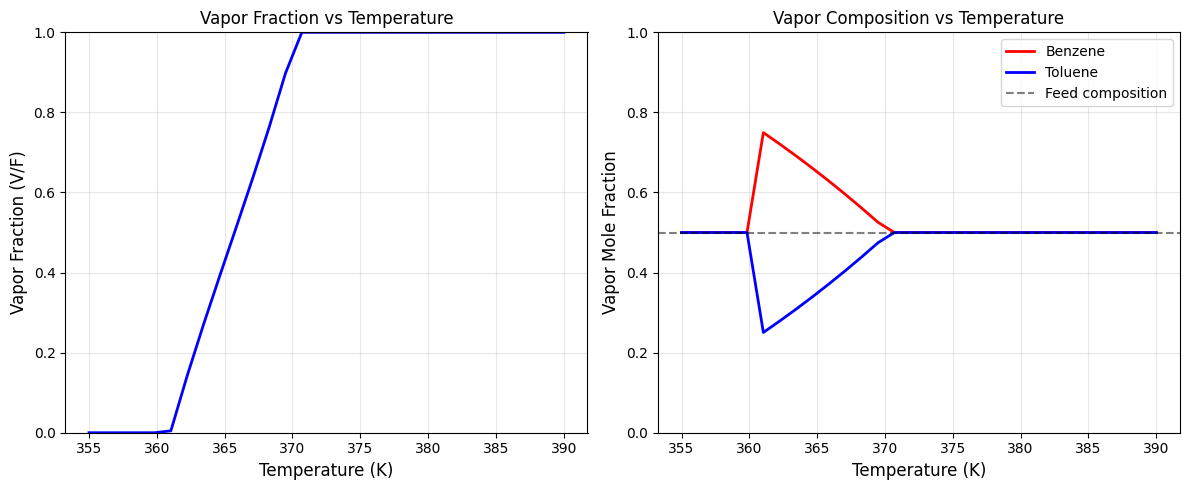

In [6]:
# How does vapor fraction change with temperature?

T_range = np.linspace(355, 390, 30)
vapor_fracs = []
y_benzene = []

for T_val in T_range:
    _, vapor, info = flash(feed, T=float(T_val), P=P)
    vapor_fracs.append(float(info['V_frac']))
    total_vapor = float(get_flows(vapor)['benzene']) + float(get_flows(vapor)['toluene'])
    if total_vapor > 0.01:
        y_benzene.append(float(get_flows(vapor)['benzene']) / total_vapor)
    else:
        y_benzene.append(0.5)  # Placeholder for no vapor

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Vapor fraction
ax = axes[0]
ax.plot(T_range, vapor_fracs, 'b-', linewidth=2)
ax.set_xlabel('Temperature (K)', fontsize=12)
ax.set_ylabel('Vapor Fraction (V/F)', fontsize=12)
ax.set_title('Vapor Fraction vs Temperature', fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)

# Right: Vapor composition
ax = axes[1]
ax.plot(T_range, y_benzene, 'r-', linewidth=2, label='Benzene')
ax.plot(T_range, [1-y for y in y_benzene], 'b-', linewidth=2, label='Toluene')
ax.axhline(y=0.5, color='k', linestyle='--', alpha=0.5, label='Feed composition')
ax.set_xlabel('Temperature (K)', fontsize=12)
ax.set_ylabel('Vapor Mole Fraction', fontsize=12)
ax.set_title('Vapor Composition vs Temperature', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)

plt.tight_layout()


## Try It Yourself!

### Exercise 1: Pressure Effect
Hold temperature constant at 370 K and vary pressure from 50 kPa to 150 kPa. How does vapor fraction change?

### Exercise 2: Three-Component Flash
Add a third component (e.g., xylene) and solve the flash. Does adding a heavier component increase or decrease the vapor fraction?

### Exercise 3: Bubble Point
Write a function to find the bubble point temperature (where V/F → 0) for a given mixture and pressure.

## End-of-Tutorial Problems

### Problem 1: K-Value Calculation
Using Antoine equation coefficients for hexane: A=9.002, B=1171.5, C=-48.8 (for log10(Psat/Pa)), calculate K at T=350K, P=101325 Pa.

### Problem 2: Flash Design
A feed of 100 mol/s (60% light, 40% heavy component) is flashed. K_light = 2.5, K_heavy = 0.4. Calculate the liquid and vapor flow rates and compositions.

### Problem 3: Sharp Separation
What K-value ratio (K_light/K_heavy) is needed to achieve 99% recovery of the light component in the vapor in a single flash?

---

## Key Takeaways

1. **K-value:** $K_i = y_i/x_i = P_i^{sat}/P$ (for ideal systems)
2. **Rachford-Rice:** Nonlinear equation to find vapor fraction
3. **Temperature effect:** Higher T → more vapor, vapor enriched in light components
4. **Pressure effect:** Higher P → less vapor
5. **Flash is a partial separation** - distillation uses multiple stages for sharp separation

---

## Next Steps

In the next notebook (**[00h: Connecting Units in Series](./00h_connecting_units_in_series.ipynb)**), we'll:
- Connect reactor + separator units
- See how outlet streams become inlet streams
- Build our first multi-unit flowsheet